# 05 — Analiza rezultata i zakljucci

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

rf = joblib.load("../models/random_forest.pkl")

X_test = pd.read_csv("../data/X_test.csv")
y_test = pd.read_csv("../data/y_test.csv").squeeze()

y_pred = rf.predict(X_test)
residuals = y_test.values - y_pred

## 1. Feature importance

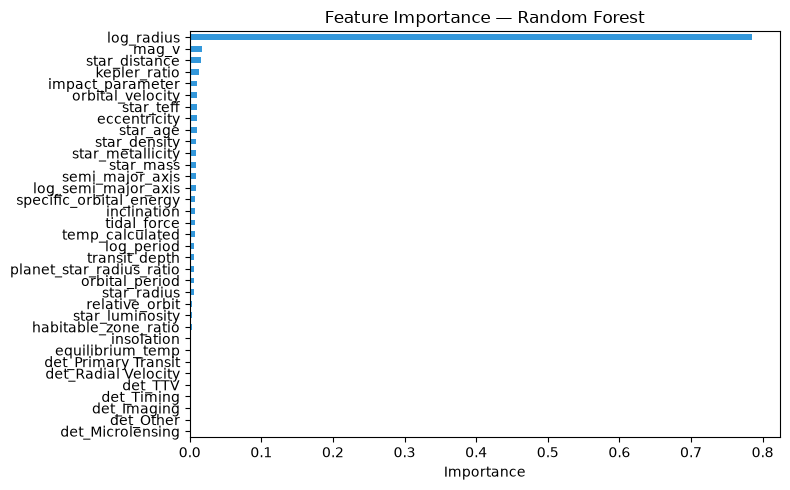

Top 3:
  star_distance: 0.0164
  mag_v: 0.0177
  log_radius: 0.7850


In [2]:
imp = pd.Series(rf.feature_importances_, index=X_test.columns).sort_values()
imp.plot(kind="barh", color="#3498db", figsize=(8, 5))
plt.xlabel("Importance")
plt.title("Feature Importance — Random Forest")
plt.tight_layout()
plt.show()

print("Top 3:")
for feat, val in imp.tail(3).items():
    print(f"  {feat}: {val:.4f}")

## 2. Gde model najvise gresi?

In [3]:
abs_error = np.abs(residuals)

bins = [-np.inf, -1, 0.5, np.inf]
labels = ["Male (< 0.1 Mj)", "Srednje (0.1-3 Mj)", "Velike (> 3 Mj)"]
grupe = pd.cut(y_test, bins=bins, labels=labels)

print("MAE po grupi planeta:")
for g in labels:
    mask = grupe == g
    print(f"  {g:25s}  MAE = {abs_error[mask].mean():.4f}  (n={mask.sum()})")

MAE po grupi planeta:
  Male (< 0.1 Mj)            MAE = 0.2405  (n=138)
  Srednje (0.1-3 Mj)         MAE = 0.2597  (n=109)
  Velike (> 3 Mj)            MAE = 0.5988  (n=17)


## 3. Zakljucci

- Random Forest je dao najbolje rezultate od sva 4 modela
- Najbitniji feature je `log_radius` — sto ima smisla jer su masa i radijus fizicki povezani
- Linearni modeli (LR i Ridge) su dosta slabiji jer ne mogu da uhvate nelinearnu vezu masa-radijus
- Model najvise gresi za velike planete (> 3 Mj) jer ih ima malo u datasetu